# Getting Started

In this tutorial, you'll learn the basics of using the `py21cmsense` library. See the [README](https://github.com/steven-murray/21cmSense) or the [CLI-tutorial](https://21cmsense.readthedocs.io/en/latest/tutorials/cli_tutorial.html) for information on the CLI interface.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as un

from py21cmsense import GaussianBeam, Observation, Observatory, PowerSpectrum, hera

%matplotlib inline

plt.style.use("dark_background")

## A Really Quick Demo

Let's first just show how to go from nothing to a power spectrum sensitivity in a few lines. You'll need the four main components of the sensitivity -- a `PrimaryBeam` (in this case, the default `GaussianBeam`), an `Observatory`, an `Observation` and a `Sensitivity` (in this case, a `PowerSpectrum` one).

We can literally construct the whole thing at once:

In [2]:
sensitivity = PowerSpectrum(
    observation=Observation(
        frequency=135.0 * un.MHz,
        observatory=Observatory(
            antpos=hera(hex_num=7, separation=14 * un.m),
            beam=GaussianBeam(dish_size=14 * un.m),
            latitude=38 * un.deg,
        ),
    )
)

<div class="alert alert-warning">

Warning

Note that this uses a default power spectrum from 21cmFAST defined at $z=9.5$. It is up to you to use a different power spectrum if your observation redshift is different.

</div>

If all we care about is the 1D power spectrum sensitivity (including thermal noise and sample variance):

In [3]:
power_std = sensitivity.calculate_sensitivity_1d()

finding redundancies: 8001ants [00:00, 366604.69ants/s]
averaging to 1D: 100%|██████████| 62/62 [00:00<00:00, 155.89kperp-bins/s]


We can plot the sensitivity:

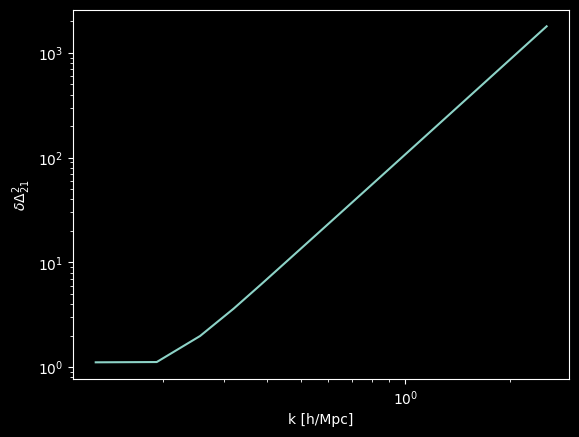

In [4]:
plt.plot(sensitivity.k1d, power_std)
plt.xlabel("k [h/Mpc]")
plt.ylabel(r"$\delta \Delta^2_{21}$")
plt.yscale("log")
plt.xscale("log")

We could also have gotten the thermal-only and sample-only variance:

In [5]:
power_std_thermal = sensitivity.calculate_sensitivity_1d(thermal=True, sample=False)
power_std_sample = sensitivity.calculate_sensitivity_1d(thermal=False, sample=True)

averaging to 1D:   0%|          | 0/62 [00:00<?, ?kperp-bins/s]

averaging to 1D: 100%|██████████| 62/62 [00:00<00:00, 150.56kperp-bins/s]


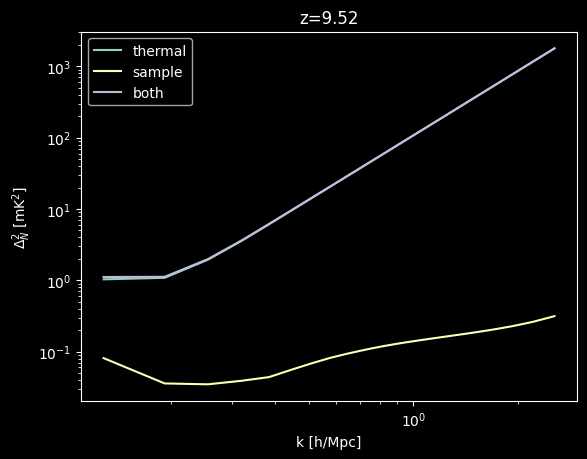

In [7]:
sensitivity.plot_sense_1d();

## The Beam Object

Let's go a bit more carefully and slowly through each of the components of the calculation. First we constructed a beam object. This can be directly accessed from our `sensitivity`:

In [8]:
beam = sensitivity.observation.observatory.beam

The beam object defines the width of the beam via the "dish size". In practice, for the purpose of `21cmSense`, it defines both the duration of an LST-bin (i.e. a set of times that for a given baseline can be coherently averaged) and the width of a UV cell (in the default settings, all baselines that fall into a given UV cell in a given LST bin are coherently averaged). It also defines the extent of the "wedge". 

Note that beam objects (and, indeed, all objects in `21cmSense`) give all their outputs with `astropy`-based units. Here's some examples:

In [9]:
beam.fwhm(sensitivity.frequency)

<Quantity 0.16774102 rad>

In [10]:
beam.uv_resolution(sensitivity.frequency)

np.float64(6.304361399245074)

In [11]:
beam.b_eff(sensitivity.frequency)

<Quantity 0.06358973 rad2>

## The `Observatory`

Next in the hierarchy of objects is the `Observatory`, which defines the attributes of the observatory itself. There are several options that can be given to its constructor, but it _requires_ an array of antenna positions and a beam object (assumed to be the same for all antennas). You can view its documentation either with the `help` function, or at [the online docs](https://21cmsense.readthedocs.io/en/latest/reference/_autosummary/observatory/py21cmsense.observatory.Observatory.html#py21cmsense.observatory.Observatory).

It also has some handy methods:

In [12]:
observatory = sensitivity.observation.observatory

We can easily make a plot of the baseline positions:

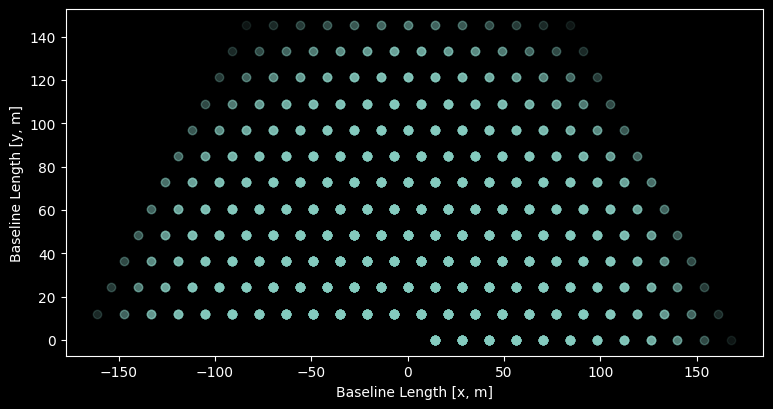

In [13]:
plt.figure(figsize=(9, 4.5))
plt.scatter(observatory.baselines_metres[..., 0], observatory.baselines_metres[..., 1], alpha=0.1)
plt.xlabel("Baseline Length [x, m]")
plt.ylabel("Baseline Length [y, m]");

Note how we only keep a single element of each conjugate pair, to save memory.

Or we can make a histogram of the baseline lengths (in wavelengths):

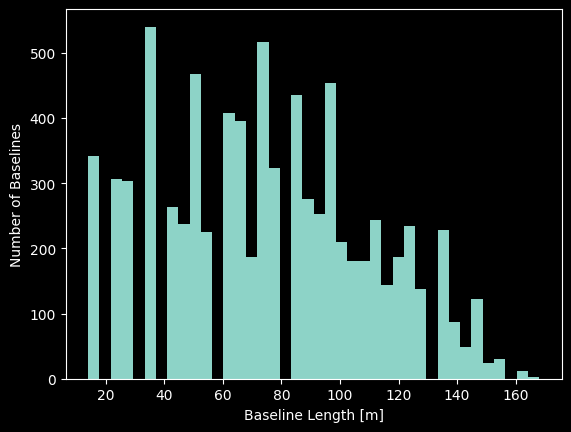

In [14]:
plt.hist(observatory.baseline_lengths.flatten(), bins=40)
plt.xlabel("Baseline Length [m]")
plt.ylabel("Number of Baselines");

The `Observatory` is in charge of the work of finding redundant baseline groups, as well as gridding the baselines (though the latter of these methods is _called_ from the `Observation` itself).

The redundant baselines are unique to the `Observatory` and so must only be computed
once and then are cached. The groups themselves (as a list of lists of integers representing baseline indices) are accessed via the 
`.redundant_baseline_groups` (cached) property.

Perhaps more useful attributes are the redundant coordinates and counts:

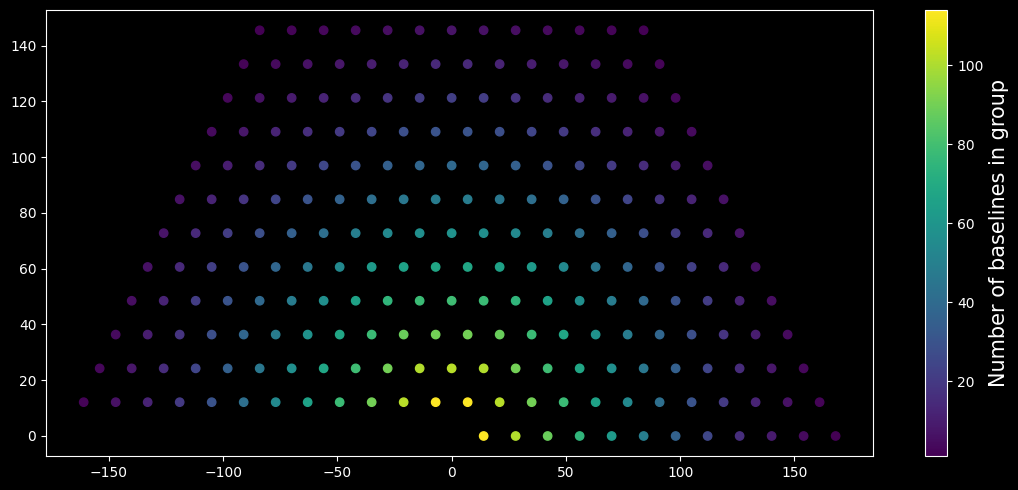

In [15]:
plt.figure(figsize=(11, 5))
plt.scatter(
    observatory.redundant_baseline_vectors[:, 0],
    observatory.redundant_baseline_vectors[:, 1],
    c=observatory.redundant_baseline_weights,
)
cbar = plt.colorbar()
cbar.set_label("Number of baselines in group", fontsize=15)
plt.tight_layout();

To grid the baselines, with rotation synthesis:

In [16]:
coherent_grid = observatory.grid_baselines(coherent=True)

And we can view this grid:

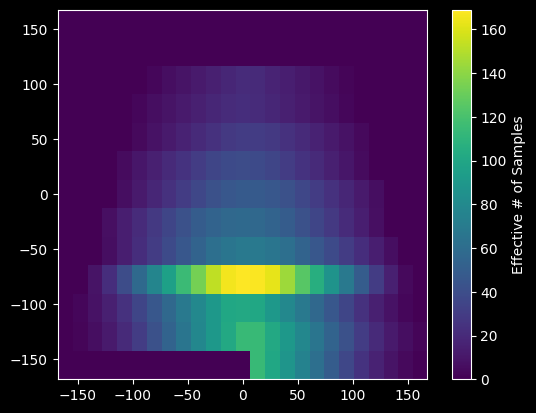

In [18]:
plt.imshow(
    coherent_grid.T,
    extent=(
        observatory.xgrid.min().to_value("m"),
        observatory.xgrid.max().to_value("m"),
    )
    * 2,
    origin="lower",
)
cbar = plt.colorbar()
cbar.set_label("Effective # of Samples")

### The `Observation`

The `Observation` object has many more user-fed parameters -- again, see them by using `help(Observation)`, or by reading the [online docs](https://21cmsense.readthedocs.io/en/latest/reference/_autosummary/observation/py21cmsense.observation.Observation.html#py21cmsense.observation.Observation).
Primarily, its job is to use these parameters to supply the `Observatory` methods with the parameters they need to derive their results.

In [19]:
observation = sensitivity.observation

We can get the total effective integration time spent in each UV cell (adjusting for coherent and incoherent averaging and all baselines):

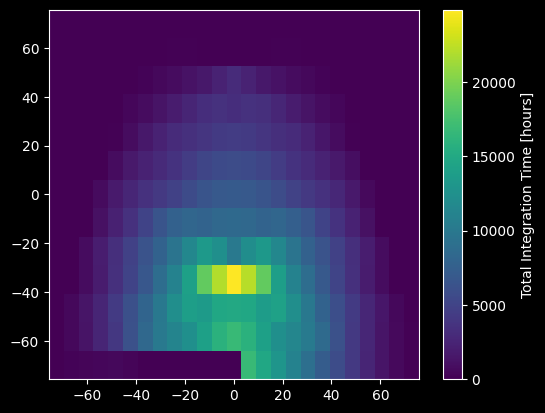

In [20]:
plt.imshow(
    observation.total_integration_time.to("hour").value.T,
    extent=(observation.ugrid.min(), observation.ugrid.max()) * 2,
    origin="lower",
)
cbar = plt.colorbar()
cbar.set_label("Total Integration Time [hours]")

One nifty feature is that you can clone any of these objects, and replace certain attributes. So we can do:

In [21]:
observation_2 = observation.clone(coherent=False)

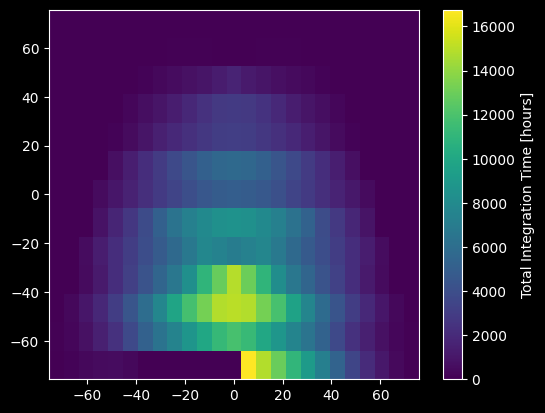

In [22]:
plt.imshow(
    observation_2.total_integration_time.to("hour").value.T,
    extent=(observation_2.ugrid.min(), observation_2.ugrid.max()) * 2,
    origin="lower",
)
cbar = plt.colorbar()
cbar.set_label("Total Integration Time [hours]")

Notice the reduction in effective integration time due to the assumption that different baseline groups cannot ever be averaged coherently.

Note also that these objects can be directly compared:

In [23]:
observation == observation_2

False

## The `Sensitivity`

The design of `21cmSense` is such that one might define sensitivity calculations for arbitrary statistical measurements from an interferometer. The default one that is implemented is the power spectrum (both 1D and 2D cylindrical).

We have already shown some methods of the `PowerSpectrum` `Sensitivity`. It also has some helpful methods to calculate horizon lines etc. Let's see what the 2D sensitivity looks like:

In [24]:
sense2d = sensitivity.calculate_sensitivity_2d()

The output here is a little strange -- a dict of arrays. It can be used to make a 2D plot though:

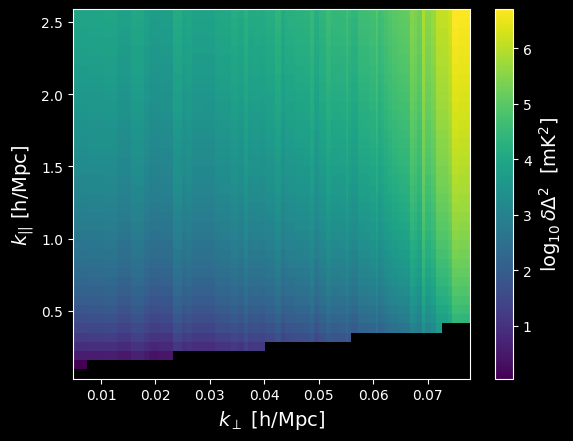

In [25]:
sensitivity.plot_sense_2d(sense2d)

Conversely, we can calculate the 2D sensitivity on a grid of $k_{\rm perp}, k_{||}$:

In [26]:
kperp = un.Quantity(np.linspace(0.01, 0.07, 15), "littleh/Mpc")
kpar = un.Quantity(np.linspace(0.1, 2, 15), "littleh/Mpc")
sense_gridded = sensitivity.calculate_sensitivity_2d_grid(kperp_edges=kperp, kpar_edges=kpar)

averaging to 2D grid: 100%|██████████| 62/62 [00:00<00:00, 3326.73kperp-bins/s]


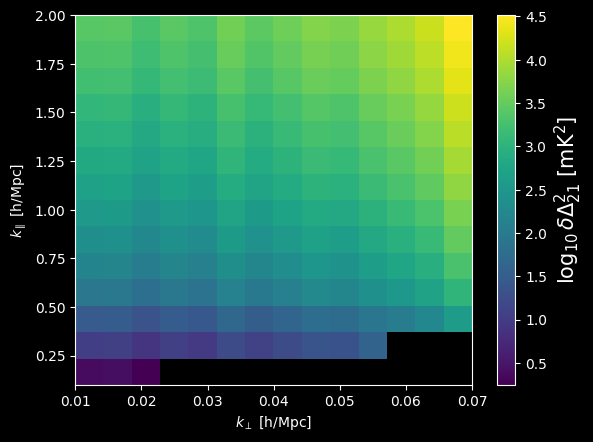

In [32]:
plt.imshow(
    np.log10(sense_gridded.value.T),
    origin="lower",
    extent=(
        kperp.min().to_value("littleh/Mpc"),
        kperp.max().to_value("littleh/Mpc"),
        kpar.min().to_value("littleh/Mpc"),
        kpar.max().to_value("littleh/Mpc"),
    ),
    aspect="auto",
)
plt.xlabel(r"$k_\perp$ [h/Mpc]")
plt.ylabel(r"$k_\parallel$ [h/Mpc]")
cmap = plt.colorbar()
cmap.set_label(r"$\log_{10} \delta \Delta^2_{21}$ [mK$^2$]", fontsize=15)

Notice the massive increase in sensitivity (lower values) because we binned in larger bins.

### Excluding arbitrary k-bins

By default, the `PowerSpectrum` sensitivity class excludes modes in the wedge (plus some optional buffer) from contributing to the sensitivity. However, a particular experiment may have certain cylindrical $k$ bins that are known to be affected by systematics (perhaps due to eg. cable reflections). You can ignore these modes by setting the `systematics_mask` parameter:

In [33]:
cable_refl_range = (un.Quantity(1.2, "littleh/Mpc"), un.Quantity(1.4, "littleh/Mpc"))
new_sense = sensitivity.clone(
    systematics_mask=lambda kperp, kpar: (
        (np.abs(kpar) < cable_refl_range[0]) | (np.abs(kpar) > cable_refl_range[1])
    )
)

calculating 2D sensitivity:  62%|██████▏   | 139/223 [00:00<00:00, 1388.61uv-bins/s]

calculating 2D sensitivity: 100%|██████████| 223/223 [00:00<00:00, 1437.93uv-bins/s]


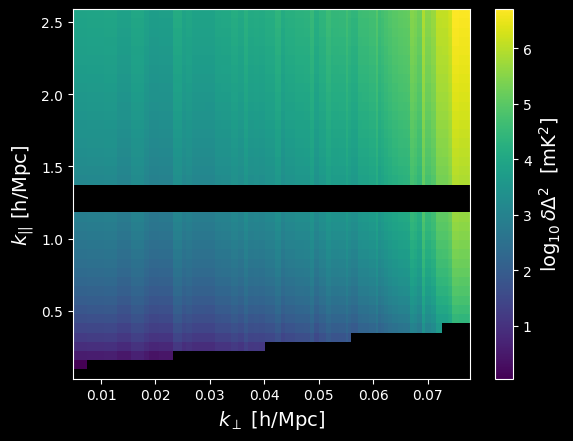

In [34]:
sense2d = new_sense.calculate_sensitivity_2d()
new_sense.plot_sense_2d(sense2d)